In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

In [2]:
patients = [patient for patient in os.listdir("Patients/RHR") if os.path.isdir(os.path.join("Patients/RHR", patient))]
len(patients)

32

In [3]:
sd_dates = pd.read_csv('Metadata/sd_dates.csv')
sd_dates["Symptom_dates"] = pd.to_datetime(sd_dates["Symptom_dates"])
sd_dates["covid_diagnosis_dates"] = pd.to_datetime(sd_dates["covid_diagnosis_dates"])

symptom_dates = sd_dates.set_index('ParticipantID')['Symptom_dates'].to_dict()
diagnosis_dates = sd_dates.set_index('ParticipantID')['covid_diagnosis_dates'].to_dict()

In [4]:
deltas_df = pd.DataFrame(columns=["patient", "delta"])
for patient in patients:
    
    try:
        df_full = pd.read_csv(f'Patients/RHR/{patient}/Anomalies/{patient}_original_anomalies.csv', header=None)
    except (FileNotFoundError, pd.errors.EmptyDataError):
        print(f"File not found or empty for patient {patient}. Skipping.")
        continue

    anom_dates = pd.DataFrame()
    anom_dates["datetime_anon"] = pd.to_datetime(df_full[1])

    symptom_date = symptom_dates.get(patient)
    diagnosis_date = diagnosis_dates.get(patient)

    if pd.isnull(symptom_date):
        if pd.isnull(diagnosis_date):
            delta = None
        else:
            df_delta = anom_dates.copy()
            if not df_delta.empty:
                df_delta['dias_diff_diag'] = (df_delta["datetime_anon"] - diagnosis_date).dt.days
                df_diff_diag = df_delta[(df_delta['dias_diff_diag'] >= -21) & (df_delta['dias_diff_diag'] <= 7)]
                if not df_diff_diag.empty:
                    closest_idx_diag = df_diff_diag['dias_diff_diag'].abs().idxmin()
                    delta = df_diff_diag.loc[closest_idx_diag, 'dias_diff_diag']
                else:
                    delta= None
            else:
                delta = None
    else:
        if not anom_dates.empty:
            df_delta = anom_dates.copy()
            df_delta['dias_diff'] = (df_delta["datetime_anon"] - symptom_date).dt.days
            df_delta = df_delta[(df_delta['dias_diff'] >= -14) & (df_delta['dias_diff'] <= 7)]
            if not df_delta.empty:
                closest_idx = df_delta.loc[df_delta['dias_diff'] <= 0, 'dias_diff'].abs().idxmin() if any(df_delta['dias_diff'] <= 0) else df_delta['dias_diff'].abs().idxmin()
                delta = df_delta.loc[closest_idx, 'dias_diff']
            else:
                if pd.isnull(diagnosis_date):
                    delta=None
                else:
                    anom_dates['dias_diff_diag'] = (anom_dates["datetime_anon"] - diagnosis_date).dt.days
                    df_diff_diag = anom_dates[(anom_dates['dias_diff_diag'] >= -21) & (anom_dates['dias_diff_diag'] <= 7)]
                    if not df_diff_diag.empty:
                        closest_idx_diag = df_diff_diag['dias_diff_diag'].abs().idxmin()
                        delta = df_diff_diag.loc[closest_idx_diag, 'dias_diff_diag']
                    else:
                        delta = None
   
    
    deltas_df = pd.concat([deltas_df, pd.DataFrame({"patient": [patient], "delta": [delta]})], ignore_index=True)


    for mech in ["MCAR", "MAR_l", "MAR_h", "MNAR_l", "MNAR_h"]:
        for mr in ["05", "10", "15", "20", "25"]:

            if f"delta_{mech}_{mr}" not in deltas_df.columns:
                deltas_df[f"delta_{mech}_{mr}"] = np.nan
            delta_mec_sum = 0 
            
            for n in range(1, 6):
                path = f"Patients/RHR/{patient}/Anomalies/{mech}/{n}/{patient}_anomalies_{mech}_{n}_{mr}.csv"
                try:
                    df_miss = pd.read_csv(path, usecols=[1, 2], header=None)
                    anom_dates_mec = pd.DataFrame()
                    anom_dates_mec["datetime_anon"] = pd.to_datetime(df_miss[1])
                except (FileNotFoundError, pd.errors.EmptyDataError):
                    anom_dates_mec = pd.DataFrame(columns=["datetime_anon"])
                
                if pd.isnull(symptom_date):
                    if pd.isnull(diagnosis_date):
                        delta_mec = None
                    else:
                        if not anom_dates_mec.empty:
                            anom_dates_mec['dias_diff_diag'] = (anom_dates_mec["datetime_anon"] - diagnosis_date).dt.days
                            df_diff_mec_diag = anom_dates_mec[(anom_dates_mec['dias_diff_diag'] >= -21) & (anom_dates_mec['dias_diff_diag'] <= 7)]
                            if not df_diff_mec_diag.empty:
                                closest_idx_diag = df_diff_mec_diag['dias_diff_diag'].abs().idxmin()
                                delta_mec = df_diff_mec_diag.loc[closest_idx_diag, 'dias_diff_diag']
                            else:
                                delta_mec = None
                        else:
                            delta_mec = None
                else:
                    if not anom_dates_mec.empty:
                        df_delta_mec = anom_dates_mec.copy()
                        df_delta_mec['dias_diff'] = (df_delta_mec["datetime_anon"] - symptom_date).dt.days
                        df_delta_mec = df_delta_mec[(df_delta_mec['dias_diff'] >= -14) & (df_delta_mec['dias_diff'] <= 7)]
                        if not df_delta_mec.empty:
                            closest_idx_mec = df_delta_mec.loc[df_delta_mec['dias_diff'] <= 0, 'dias_diff'].abs().idxmin() if any(df_delta_mec['dias_diff'] <= 0) else df_delta_mec['dias_diff'].abs().idxmin()
                            delta_mec = df_delta_mec.loc[closest_idx_mec, 'dias_diff']
                        else:
                            if pd.isnull(diagnosis_date):
                                delta_mec = None
                            else:
                                if not anom_dates_mec.empty:
                                    anom_dates_mec['dias_diff_diag'] = (anom_dates_mec["datetime_anon"] - diagnosis_date).dt.days
                                    df_diff_mec_diag = anom_dates_mec[(anom_dates_mec['dias_diff_diag'] >= -21) & (anom_dates_mec['dias_diff_diag'] <= 7)]
                                    if not df_diff_mec_diag.empty:
                                        closest_idx_diag = df_diff_mec_diag['dias_diff_diag'].abs().idxmin()
                                        delta_mec = df_diff_mec_diag.loc[closest_idx_diag, 'dias_diff_diag']
                                    else:
                                        delta_mec = None
                                else:
                                    delta_mec = None

                    # You can now use delta_mec as needed (e.g., accumulate, store, etc.)
                delta_mec_sum += 30 if delta_mec is None else delta_mec

            delta_median = delta_mec_sum / 5
            if delta_median == 30:
                delta_median = None
            idx = deltas_df.index[deltas_df["patient"] == patient]
            deltas_df.loc[idx[0], f"delta_{mech}_{mr}"] = delta_median

deltas_df

File not found or empty for patient AJ7TSV9. Skipping.


,patient,delta,delta_MCAR_05,delta_MCAR_10,delta_MCAR_15,delta_MCAR_20,delta_MCAR_25,delta_MAR_l_05,delta_MAR_l_10,delta_MAR_l_15,...,delta_MNAR_l_05,delta_MNAR_l_10,delta_MNAR_l_15,delta_MNAR_l_20,delta_MNAR_l_25,delta_MNAR_h_05,delta_MNAR_h_10,delta_MNAR_h_15,delta_MNAR_h_20,delta_MNAR_h_25
0,A1ZJ41O,1,0.6,0.4,0.6,0.2,0.2,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,-1.0,1.0,1.0,2.0,2.4
1,AKXN5ZZ,0,0.0,0.2,0.2,0.4,0.8,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.2,0.0,0.0,0.0,0.0,0.0
2,AAXAA7Z,5,5.0,5.0,5.0,5.0,4.0,5.0,5.0,5.0,...,0.0,0.0,0.0,0.0,0.0,5.0,5.0,5.0,1.8,1.0
3,AA2KP1S,3,3.0,3.0,3.0,3.4,3.4,3.0,3.0,4.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,NaN
4,APGIB2T,-2,-2.0,-2.0,-2.4,-2.0,-2.6,-2.0,-2.0,-2.0,...,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-4.0,-3.6,-2.4
5,AHYIJDV,1,1.0,1.0,1.0,1.2,1.4,1.0,1.0,1.0,...,1.0,1.0,-6.2,-7.0,1.0,1.0,1.0,1.8,1.0,1.0
6,ASFODQR,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,AUY8KYW,-12,-12.0,-13.2,-14.0,-5.0,-5.6,-12.0,-10.0,-9.0,...,-11.4,-10.0,-8.6,-8.6,NaN,-12.0,-12.0,-14.0,-14.0,-15.0
8,A3OU183,-1,-1.0,-1.0,-1.0,-8.8,-11.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-6.4,6.0,-13.0,-13.0
9,AOYM4KG,-1,-1.0,0.6,0.6,0.4,0.2,-1.0,1.0,1.0,...,-4.0,-3.0,-3.0,-3.0,-3.0,-1.0,-1.0,-1.0,1.0,1.0


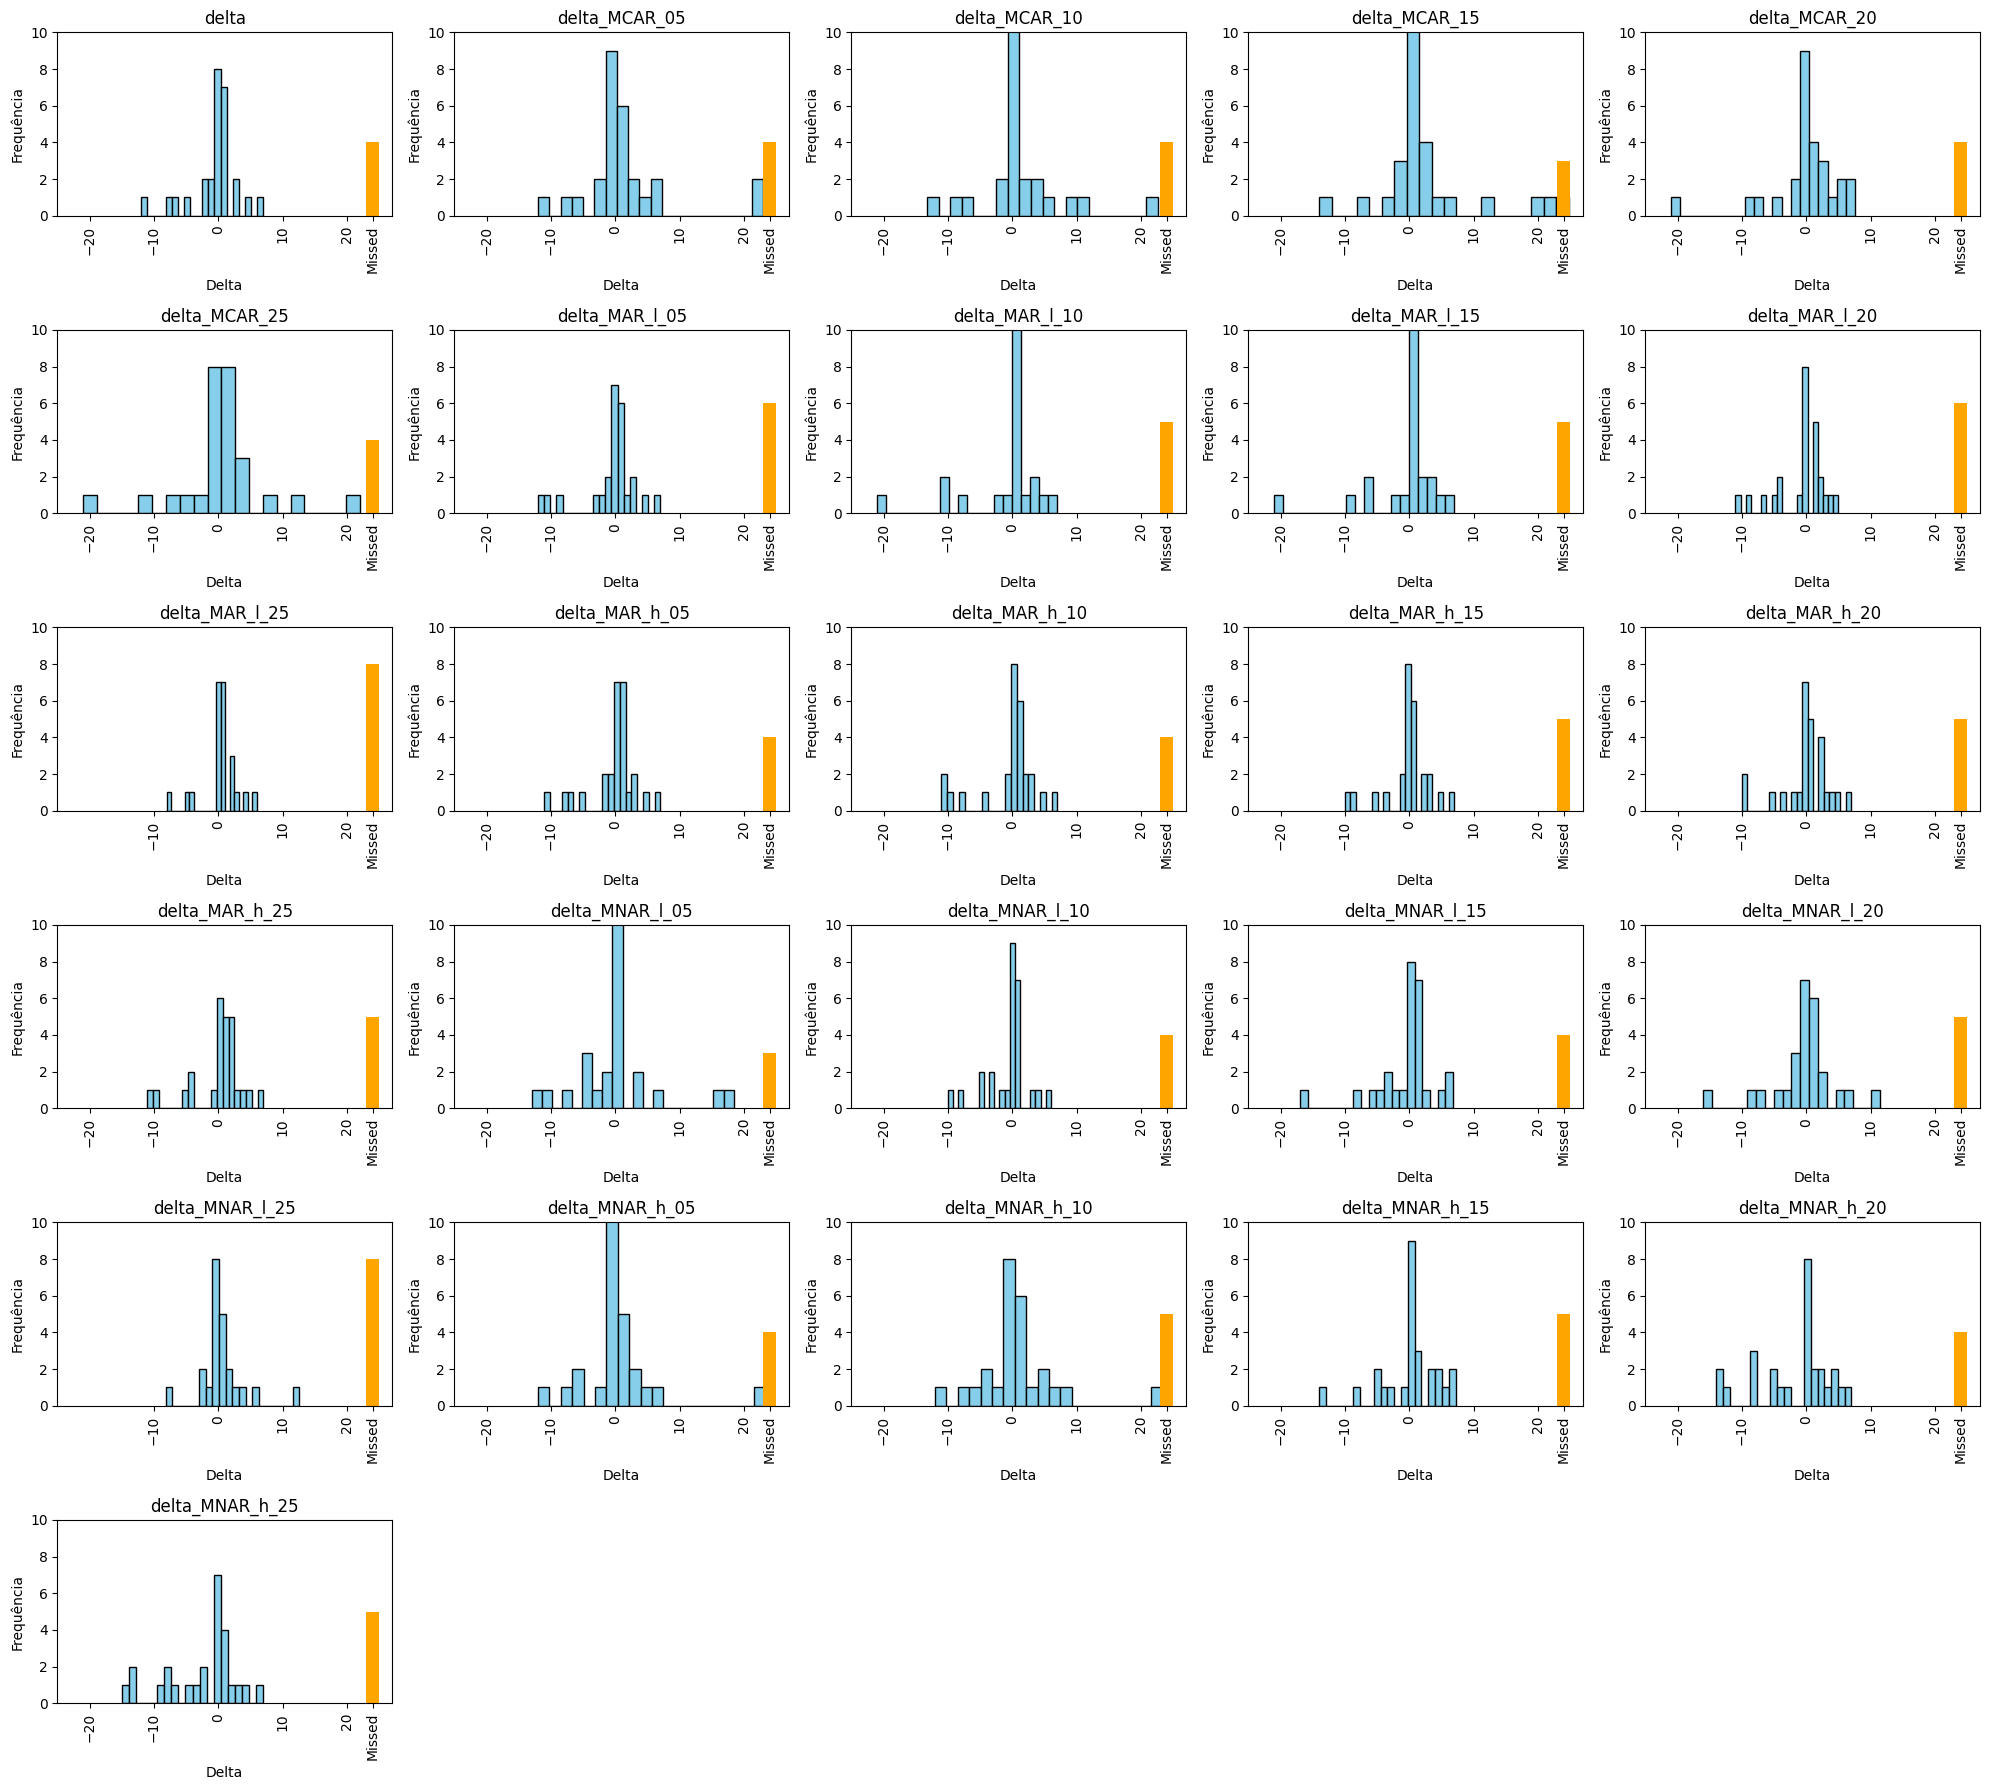

In [11]:
import math
import numpy as np

# Para cada coluna de delta (exceto 'patient' e 'delta'), plote um histograma

# Seleciona as colunas de deltas_df que começam com 'delta_' (exceto 'delta') para análise
delta_cols = [col for col in deltas_df.columns if col.startswith('delta')]

num_cols = len(delta_cols)
cols_per_row = 5
num_rows = math.ceil(num_cols / cols_per_row)

fig, axs = plt.subplots(num_rows, cols_per_row, figsize=(cols_per_row * 4, num_rows * 3))
axs = axs.flatten()
# Defina os limites do eixo x iguais para todos os subplots
# Substitui None por np.nan para uniformizar
for col in delta_cols:
    deltas_df[col] = deltas_df[col].replace({None: np.nan})

# Conta NaN/None para cada coluna
nan_counts = [deltas_df[col].isna().sum() for col in delta_cols]

# Plota os NaN/None como uma barra extra em cada histograma
for idx, col in enumerate(delta_cols):
    ax = axs[idx]
    data = deltas_df[col].dropna()
    ax.hist(data, bins=20, color='skyblue', edgecolor='black')
    # Adiciona barra para NaN/None
    if nan_counts[idx] > 0:
        ax.bar(24, nan_counts[idx], width=2, color='orange', label='NaN/None')
        ax.set_xticks(list(ax.get_xticks()) + [24])
        ax.set_xticklabels([*ax.get_xticklabels()[:-1], 'Missed'], rotation=90)
    ax.set_title(col)
    ax.set_xlabel('Delta')
    ax.set_ylabel('Frequência')
    ax.set_xlim(-25, 27)
    ax.set_ylim(0, 10)

# Remove subplots vazios
for idx in range(num_cols, len(axs)):
    fig.delaxes(axs[idx])

plt.tight_layout()
plt.show()

In [14]:
from scipy.stats import ks_2samp, mannwhitneyu

# Seleciona as colunas de deltas_df que começam com 'delta_' (exceto 'delta')
delta_cols_ks = [col for col in deltas_df.columns if col.startswith('delta_') and col != 'delta']

ks_results = {}

for col in delta_cols_ks:
    # Remove NaN para o teste
    data1 = deltas_df['delta'].dropna()
    data2 = deltas_df[col].dropna()
    # Só faz o teste se ambos tiverem pelo menos 2 valores
    stat, pvalue = mannwhitneyu(data1, data2)
    ks_results[col] = {'statistic': stat, 'pvalue': pvalue}
 

# Mostra os resultados em um DataFrame ordenado pelo p-valor
ks_df = pd.DataFrame(ks_results).T.sort_values('pvalue')
# Adiciona uma coluna indicando se o resultado é significativo ao nível de 5%
ks_df['significativo_5%'] = ks_df['pvalue'] < 0.05
ks_df['significativo_1%'] = ks_df['pvalue'] < 0.01

# Exibe os resultados
print(ks_df)

                 statistic    pvalue  significativo_5%  significativo_1%
delta_MNAR_h_25      438.0  0.114386             False             False
delta_MNAR_h_20      434.0  0.219197             False             False
delta_MCAR_25        295.0  0.318581             False             False
delta_MNAR_l_05      403.0  0.335008             False             False
delta_MAR_h_25       299.5  0.346067             False             False
delta_MAR_h_20       307.5  0.424816             False             False
delta_MCAR_20        308.5  0.443720             False             False
delta_MAR_l_05       376.0  0.451626             False             False
delta_MAR_l_15       298.0  0.452665             False             False
delta_MAR_l_25       279.0  0.532352             False             False
delta_MNAR_h_05      380.0  0.578095             False             False
delta_MNAR_l_15      377.5  0.631896             False             False
delta_MCAR_15        325.0  0.641806             Fa

In [12]:
# Para cada coluna delta_... em deltas_df, calcula a diferença com a coluna 'delta' e salva em uma nova coluna delta_f...
for col in deltas_df.columns:
    if col.startswith('delta_') and col != 'delta':
        # Converte para float para evitar problemas de tipos
        deltas_df[col] = deltas_df[col].astype(float) - pd.to_numeric(deltas_df['delta'], errors='coerce')

deltas_df

,patient,delta,delta_MCAR_05,delta_MCAR_10,delta_MCAR_15,delta_MCAR_20,delta_MCAR_25,delta_MAR_l_05,delta_MAR_l_10,delta_MAR_l_15,...,delta_MNAR_l_05,delta_MNAR_l_10,delta_MNAR_l_15,delta_MNAR_l_20,delta_MNAR_l_25,delta_MNAR_h_05,delta_MNAR_h_10,delta_MNAR_h_15,delta_MNAR_h_20,delta_MNAR_h_25
0,A1ZJ41O,1.0,-0.4,-0.6,-0.4,-0.8,-0.8,0.0,0.0,0.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-2.0,0.0,0.0,1.0,1.4
1,AKXN5ZZ,0.0,0.0,0.2,0.2,0.4,0.8,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.2,0.0,0.0,0.0,0.0,0.0
2,AAXAA7Z,5.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,...,-5.0,-5.0,-5.0,-5.0,-5.0,0.0,0.0,0.0,-3.2,-4.0
3,AA2KP1S,3.0,0.0,0.0,0.0,0.4,0.4,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,NaN
4,APGIB2T,-2.0,0.0,0.0,-0.4,0.0,-0.6,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,-1.6,-0.4
5,AHYIJDV,1.0,0.0,0.0,0.0,0.2,0.4,0.0,0.0,0.0,...,0.0,0.0,-7.2,-8.0,0.0,0.0,0.0,0.8,0.0,0.0
6,ASFODQR,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,AUY8KYW,-12.0,0.0,-1.2,-2.0,7.0,6.4,0.0,2.0,3.0,...,0.6,2.0,3.4,3.4,NaN,0.0,0.0,-2.0,-2.0,-3.0
8,A3OU183,-1.0,0.0,0.0,0.0,-7.8,-10.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-5.4,7.0,-12.0,-12.0
9,AOYM4KG,-1.0,0.0,1.6,1.6,1.4,1.2,0.0,2.0,2.0,...,-3.0,-2.0,-2.0,-2.0,-2.0,0.0,0.0,0.0,2.0,2.0


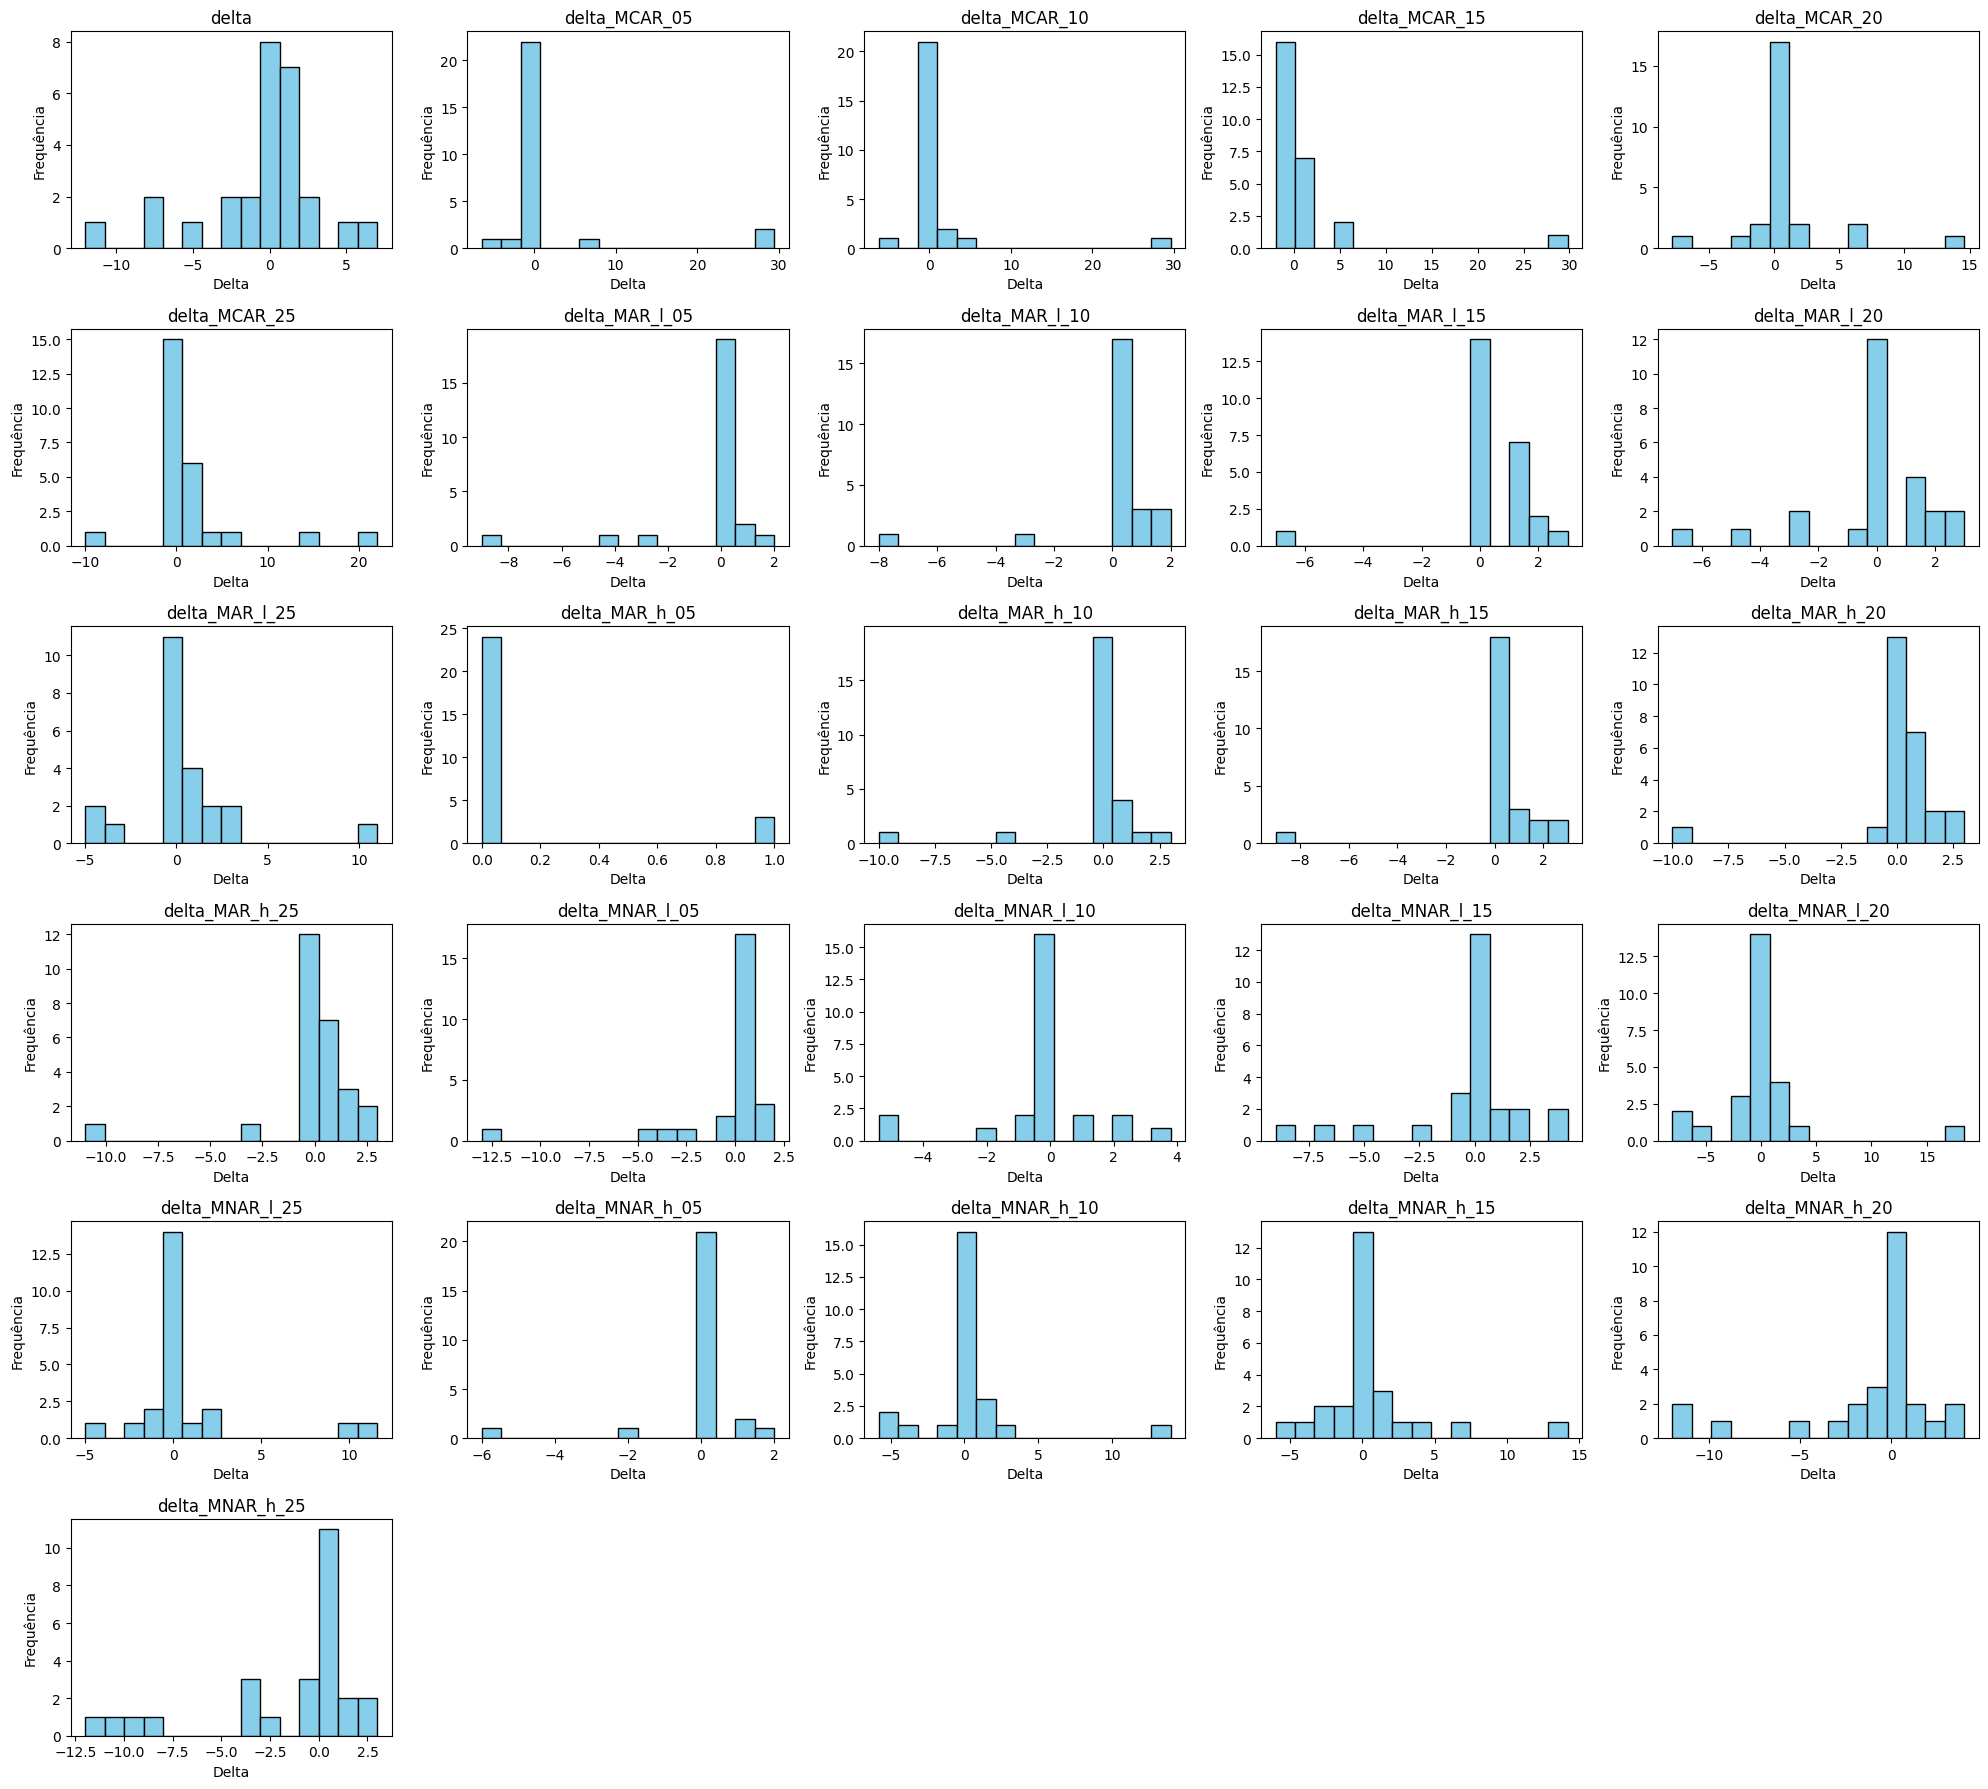

In [13]:
import math

# Para cada coluna de delta (exceto 'patient' e 'delta'), plote um histograma

num_cols = len(delta_cols)
cols_per_row = 5
num_rows = math.ceil(num_cols / cols_per_row)

fig, axs = plt.subplots(num_rows, cols_per_row, figsize=(cols_per_row * 4, num_rows * 3))
axs = axs.flatten()

for idx, col in enumerate(delta_cols):
    ax = axs[idx]
    data = deltas_df[col].dropna()
    ax.hist(data, bins=15, color='skyblue', edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('Delta')
    ax.set_ylabel('Frequência')

# Remove subplots vazios
for idx in range(num_cols, len(axs)):
    fig.delaxes(axs[idx])

plt.tight_layout()
plt.show()

In [ ]:
# Select the patient of interest, e.g., 'A7EM0B6'
patient_id = 'A7EM0B6'

# Filter the row for the given patient
row = deltas_df[deltas_df['patient'] == patient_id]

# Select only the delta columns (excluding 'patient' and 'delta')
delta_cols = [col for col in deltas_df.columns if col.startswith('delta_')]
y = row[delta_cols].iloc[0]

# Prepare x-axis labels (mechanism and missing rate)
x = delta_cols
# Split delta columns by mechanism
mechs = ['MCAR', 'MAR_l', 'MAR_h', 'MNAR_l', 'MNAR_h']
mr_values = ["05", "10", "15", "20", "25"]

plt.figure(figsize=(14, 5))
for mech in mechs:
    mech_cols = [col for col in delta_cols if f'delta_{mech}_' in col]
    y_mech = row[mech_cols].iloc[0]
    x_mech = [col.split('_')[-1] for col in mech_cols]
    plt.plot(x_mech, y_mech, marker='o', label=mech)

plt.xticks(mr_values)
plt.xlabel('Missing Rate')
plt.ylabel('Delta')
plt.title(f'Delta values for patient {patient_id}')
plt.legend(title='Mechanism')
plt.tight_layout()
plt.show()